*Analytical Task 4* : How Goal against goalkeepers varied for keepers of all teams, and what significance it had for teams reaching knockout stages

First, we perform *data wrangling*. For this particular analytical task we use dataset -> dataset_task4.xlsx

Fetch data into dataframe object and remove unnecessary columns from the dataframe.

In [1]:
import pandas as pd
import numpy as np

dataframe = pd.read_excel("../raw_datasets/dataset_task4.xlsx")
print(dataframe.head())

   Rk             Player      Squad  Age  Born  MP  Starts  Min  90s  GA  \
0   1    Yazeed Abulaila  jo Jordan   33  1993   3       3  270  3.0   8   
1   2    Mahmoud Abunada   qa Qatar   26  2000   3       3  270  3.0  10   
2   3            Alisson  br Brazil   33  1992   5       5  450  5.0   4   
3   4     Benjamin Asare   gh Ghana   33  1992   3       2  225  2.5   2   
4   5  Lawrence Ati-Zigi   gh Ghana   29  1996   2       2  135  1.5   1   

   GA90  SoTA  Saves  Save%  W  D  L  CS    CS%  
0  2.67    16      8   50.0  0  0  3   0    0.0  
1  3.33    22     12   54.5  0  1  2   0    0.0  
2  0.80    18     14   77.8  3  1  1   2   40.0  
3  0.80    10      8   80.0  0  1  1   2  100.0  
4  0.67     9      8   88.9  1  0  1   1   50.0  


In [2]:
# Selected columns to keep in the dataframe
columns_to_keep = ["Rk", "Player", "Squad", "MP", "Min", "GA", "GA90", "Save%"] 

# Update the dataframe to only include the selected columns
dataframe = dataframe[columns_to_keep].copy()

#Rename the columns to more descriptive names
dataframe.rename(columns={
    "Rk": "Rank",
    "Squad": "Team",
    "MP": "Matches_Played",
    "Min": "Minutes_Played",
    "GA": "Goals_Against",
    "GA90": "Goals_Against_per_90_Minutes",
    "Save%": "Save_Percentage"
},
inplace=True)

# The Team name has abbreviations, so we will remove the first few characters from the Team column to get the full team name
dataframe["Team"] = dataframe["Team"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)

print(dataframe.info())

<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Rank                          62 non-null     int64  
 1   Player                        62 non-null     str    
 2   Team                          62 non-null     str    
 3   Matches_Played                62 non-null     int64  
 4   Minutes_Played                62 non-null     int64  
 5   Goals_Against                 62 non-null     int64  
 6   Goals_Against_per_90_Minutes  62 non-null     float64
 7   Save_Percentage               59 non-null     float64
dtypes: float64(2), int64(4), str(2)
memory usage: 4.0 KB
None


Now, we want data to be differentiated for teams that reached knockout stage and those that only played group stage.

For teams that only played group stage - Total team minutes played will be about 270 minutes because each team played 3 matches

For other teams it will be greater than 270 minutes

In [3]:
total_team_minutes = dataframe.groupby("Team")["Minutes_Played"].transform("sum")

dataframe["Stage"] = np.where(total_team_minutes > 270, "Knockout", "Group Stage")

print(dataframe.head())

   Rank             Player    Team  Matches_Played  Minutes_Played  \
0     1    Yazeed Abulaila  Jordan               3             270   
1     2    Mahmoud Abunada   Qatar               3             270   
2     3            Alisson  Brazil               5             450   
3     4     Benjamin Asare   Ghana               3             225   
4     5  Lawrence Ati-Zigi   Ghana               2             135   

   Goals_Against  Goals_Against_per_90_Minutes  Save_Percentage        Stage  
0              8                          2.67             50.0  Group Stage  
1             10                          3.33             54.5  Group Stage  
2              4                          0.80             77.8     Knockout  
3              2                          0.80             80.0     Knockout  
4              1                          0.67             88.9     Knockout  


Check and remove any player that played less than 180 minutes (2 full matches)

In [4]:
dataframe = dataframe[dataframe["Minutes_Played"] >= 180].copy()

#Also remove any players with no records of Goals Against, GA90, or Save Percentage
dataframe = dataframe.dropna(subset=["Goals_Against", "Goals_Against_per_90_Minutes", "Save_Percentage"]).reset_index(drop=True)

print(dataframe.info())
print(dataframe.head())

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Rank                          48 non-null     int64  
 1   Player                        48 non-null     str    
 2   Team                          48 non-null     str    
 3   Matches_Played                48 non-null     int64  
 4   Minutes_Played                48 non-null     int64  
 5   Goals_Against                 48 non-null     int64  
 6   Goals_Against_per_90_Minutes  48 non-null     float64
 7   Save_Percentage               48 non-null     float64
 8   Stage                         48 non-null     str    
dtypes: float64(2), int64(4), str(3)
memory usage: 3.5 KB
None
   Rank           Player       Team  Matches_Played  Minutes_Played  \
0     1  Yazeed Abulaila     Jordan               3             270   
1     2  Mahmoud Abunada      Qatar               3    

From the cleaned data, we create a sample to perform analysis.

Considering our analytical task, we should create a sample containing random 15 group stage teams and 15 knockout stage teams. We can achieve that by balanced stratified sampling

In [5]:
# So, perform stratified sampling
sample_dataframe = (
                    dataframe.groupby("Stage", as_index=False, group_keys=False)
                            .sample(n=15,random_state=42)
                            .reset_index(drop=True)
)

# Verification
print("Size of Sample DataFrame:", len(sample_dataframe))
print(sample_dataframe.head())
print(sample_dataframe["Stage"].value_counts())

Size of Sample DataFrame: 30
   Rank             Player          Team  Matches_Played  Minutes_Played  \
0    35   Fernando Muslera       Uruguay               3             225   
1    41  Mohammed Al-Owais  Saudi Arabia               3             270   
2     1    Yazeed Abulaila        Jordan               3             270   
3    46          Eloy Room       Curaçao               3             270   
4    17       Aymen Dahmen       Tunisia               2             180   

   Goals_Against  Goals_Against_per_90_Minutes  Save_Percentage        Stage  
0              4                          1.60             50.0  Group Stage  
1              5                          1.67             76.2  Group Stage  
2              8                          2.67             50.0  Group Stage  
3              9                          3.00             69.0  Group Stage  
4              7                          3.50             41.7  Group Stage  
Stage
Group Stage    15
Knockout       1

In [6]:
# Descriptive statistics for the sample dataframe
target_column = "Goals_Against_per_90_Minutes"

print("Descriptive Statistics")
print(f"Mean : {sample_dataframe[target_column].mean():.3f}")
print(f"Median : {sample_dataframe[target_column].median():.3f}")
print(f"Standard Deviation : {sample_dataframe[target_column].std():.3f}")
print(f"Variance : {sample_dataframe[target_column].var():.3f}")

Descriptive Statistics
Mean : 1.765
Median : 1.330
Standard Deviation : 0.988
Variance : 0.977


Checking the descriptive stats according to stages i.e for both group stage and knockout teams

In [7]:
print("Descriptive Statistics for Group Stage")
group_stage_data = sample_dataframe[sample_dataframe['Stage'] == 'Group Stage'][target_column]

print(f"Mean : {group_stage_data.mean():.3f}")
print(f"Median : {group_stage_data.median():.3f}")
print(f"Standard Deviation : {group_stage_data.std():.3f}")
print(f"Variance : {group_stage_data.var():.3f}")

print("Descriptive Statistics for Knockout Stage")
knockout_stage_data = sample_dataframe[sample_dataframe['Stage'] == 'Knockout'][target_column]

print(f"Mean : {knockout_stage_data.mean():.3f}")
print(f"Median : {knockout_stage_data.median():.3f}")
print(f"Standard Deviation : {knockout_stage_data.std():.3f}")
print(f"Variance : {knockout_stage_data.var():.3f}")

# Checking Quartiles and IQR for the target column
print("Quartiles and IQR for the target column")
print(f"Q1 Group Stage : {group_stage_data.quantile(0.25):.3f}")
print(f"Q3 Group Stage : {group_stage_data.quantile(0.75):.3f}")
print(f"IQR Group Stage : {group_stage_data.quantile(0.75) - group_stage_data.quantile(0.25):.3f}")

print(f"Q1 Knockout Stage : {knockout_stage_data.quantile(0.25):.3f}")
print(f"Q3 Knockout Stage : {knockout_stage_data.quantile(0.75):.3f}")
print(f"IQR Knockout Stage : {knockout_stage_data.quantile(0.75) - knockout_stage_data.quantile(0.25):.3f}")

Descriptive Statistics for Group Stage
Mean : 2.273
Median : 2.000
Standard Deviation : 0.994
Variance : 0.989
Descriptive Statistics for Knockout Stage
Mean : 1.257
Median : 1.130
Standard Deviation : 0.695
Variance : 0.482
Quartiles and IQR for the target column
Q1 Group Stage : 1.465
Q3 Group Stage : 3.165
IQR Group Stage : 1.700
Q1 Knockout Stage : 0.975
Q3 Knockout Stage : 1.280
IQR Knockout Stage : 0.305


Let's plot graph using this IQR to check outliers

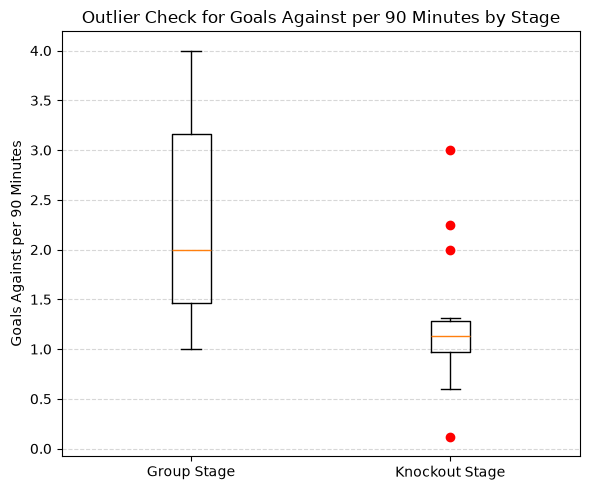

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.boxplot(
    [group_stage_data, knockout_stage_data],
    flierprops=dict(
        marker='o', markerfacecolor='red', markeredgecolor='red', markersize=6)
)

plt.xticks([1, 2], ['Group Stage', 'Knockout Stage'])
plt.title("Outlier Check for Goals Against per 90 Minutes by Stage")
plt.ylabel("Goals Against per 90 Minutes")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Confidence Interval of the mean with 95% confidence level

In [9]:
import scipy.stats as stats
import statsmodels.stats.weightstats as stm

z_score = stats.norm.ppf(0.975)
print(f"Z-Score for 95% Confidence Interval: {z_score:.3f}")

standard_error_group_stage = stats.tstd(group_stage_data) / np.sqrt(len(group_stage_data))
margin_of_error_group_stage = z_score * standard_error_group_stage
confidence_interval_group_stage_lower = group_stage_data.mean() - margin_of_error_group_stage
confidence_interval_group_stage_upper = group_stage_data.mean() + margin_of_error_group_stage

standard_error_knockout_stage = stats.tstd(knockout_stage_data) / np.sqrt(len(knockout_stage_data))
margin_of_error_knockout_stage = z_score * standard_error_knockout_stage
confidence_interval_knockout_stage_lower = knockout_stage_data.mean() - margin_of_error_knockout_stage
confidence_interval_knockout_stage_upper = knockout_stage_data.mean() + margin_of_error_knockout_stage

print(f"95% Confidence Interval for Group Stage: {confidence_interval_group_stage_lower:.3f} to {confidence_interval_group_stage_upper:.3f}")
print(f"95% Confidence Interval for Knockout Stage: {confidence_interval_knockout_stage_lower:.3f} to {confidence_interval_knockout_stage_upper:.3f}")

Z-Score for 95% Confidence Interval: 1.960
95% Confidence Interval for Group Stage: 1.770 to 2.777
95% Confidence Interval for Knockout Stage: 0.906 to 1.609


In [10]:
# Verification using statsmodels
confidence_interval_lower, confidence_interval_upper = stm._zconfint_generic(
    stats.tmean(group_stage_data), 
    standard_error_group_stage, 
    0.05, alternative='two-sided'
)

print("Verification using statsmodels:")
print(f"95% Confidence Interval for Group Stage: {confidence_interval_lower:.3f} to {confidence_interval_upper:.3f}")

Verification using statsmodels:
95% Confidence Interval for Group Stage: 1.770 to 2.777


Plot for confidence interval for mean of goal against per 90 minutes for samples of group stage and knockout stage

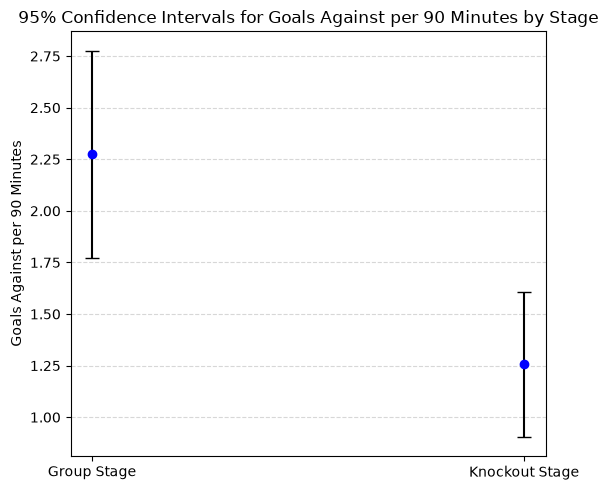

In [11]:
plt.figure(figsize=(6, 5))
plt.errorbar(
    ["Group Stage", "Knockout Stage"],
    [stats.tmean(group_stage_data), stats.tmean(knockout_stage_data)],
    yerr=[margin_of_error_group_stage, margin_of_error_knockout_stage],
    fmt='o', 
    color='blue', 
    ecolor='black', 
    capsize=5,
    elinewidth=1.5,
    markersize=6
)

plt.title("95% Confidence Intervals for Goals Against per 90 Minutes by Stage")
plt.ylabel("Goals Against per 90 Minutes")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Two-Sample T-Test

Here our hypothesis is as follows:

Null Hypothesis where mean for group stage and knockout stage should be similar or equal
While, alternative hypothesis when there is significant difference in mean between group stage and knockout stage

In [12]:
t_stats, p_value = stats.ttest_ind_from_stats(
    stats.tmean(group_stage_data),
    stats.tstd(group_stage_data),
    len(group_stage_data),
    stats.tmean(knockout_stage_data),
    stats.tstd(knockout_stage_data),
    len(knockout_stage_data),
    equal_var=False,
    alternative='two-sided'
)

degree_of_freedom = (stats.tstd(group_stage_data)**2 / len(group_stage_data) + stats.tstd(knockout_stage_data)**2 / len(knockout_stage_data))**2 / (
    (stats.tstd(group_stage_data)**2 / len(group_stage_data))**2 / (len(group_stage_data) - 1) +
    (stats.tstd(knockout_stage_data)**2 / len(knockout_stage_data))**2 / (len(knockout_stage_data) - 1)
)

print(f"T-Statistic: {t_stats:.3f}, Degrees of Freedom: {degree_of_freedom:.2f}, P-Value: {p_value:.3f}")
print("Conclusion:")
if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference in the means of Goals Against per 90 Minutes between Group Stage and Knockout Stage.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in the means of Goals Against per 90 Minutes between Group Stage and Knockout Stage.")

T-Statistic: 3.244, Degrees of Freedom: 25.04, P-Value: 0.003
Conclusion:
Reject the null hypothesis. There is a significant difference in the means of Goals Against per 90 Minutes between Group Stage and Knockout Stage.
